# The federated backbone — drift detection under dependence, and dependence detected

**fedwater** · continuation of `simulator_story.ipynb`. Reads only Kedro
catalog artifacts from three worlds: the coupled **baseline**, **partial-50%**
(5/9 boundaries closed, anchor 0.04 for serviceability), and **isolated**
(own sources). Variant worlds are built by `make_variant` below if absent
(cache-or-run), each ≈ 6 min: simulation → FL → dependence.

In [1]:
from pathlib import Path
import subprocess, os, shutil, copy, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, matplotlib as mpl
import numpy as np, pandas as pd, yaml

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = PROJECT / "data/08_reporting/figures"; FIGS.mkdir(parents=True, exist_ok=True)
mpl.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "figure.constrained_layout.use": True})
CLR = dict(zip([f"District_{x}" for x in "ABCDE"],
               ["#0173b2", "#de8f05", "#029e73", "#d55e00", "#cc78bc"]))
def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIGS / f"{name}.pdf", bbox_inches="tight")
    print("saved", name)

def make_variant(path, coupling, anchor=None):
    """Cache-or-run: build a variant world (sim -> fl -> dependence)."""
    path = Path(path)
    if (path / "data/08_reporting/client_dependence.csv").exists():
        return path
    if path.exists(): shutil.rmtree(path)
    shutil.copytree(PROJECT, path, ignore=shutil.ignore_patterns(
        "__pycache__", ".pytest_cache", "notebooks", "02_intermediate"))
    params = yaml.safe_load(open(path / "conf/base/parameters.yml"))
    o = {"coupling": coupling,
         "oracle": {**copy.deepcopy(params["oracle"]), "tiers": [1],
                    "n_surrogates": 10, "n_surrogates_expensive": 5},
         "fl": copy.deepcopy(params["fl"])}
    o["fl"]["preprocessing"]["step_size"] = 2
    o["fl"]["training"]["batch_size"] = 128
    if anchor: o["hydraulics"] = {"anchor_scale": anchor,
                                  "demand_multiplier": 1.0, "demand_model": "DD"}
    (path / "conf/local/parameters.yml").write_text(yaml.safe_dump(o))
    env = {**os.environ, "KEDRO_LOGGING_CONFIG": ""}
    for pl in (None, "fl", "dependence_detection"):
        cmd = ["kedro", "run"] + (["--pipeline", pl] if pl else [])
        r = subprocess.run(cmd, cwd=path, env=env, capture_output=True, text=True)
        assert r.returncode == 0, r.stdout[-1500:]
    return path

WORLDS = {
  "baseline": PROJECT,
  "partial_50": make_variant("/tmp/fedwater_p50",
      {"variant": "partial", "close_fraction": 0.5}, anchor=0.04),
  "isolated": make_variant("/tmp/fedwater_iso",
      {"variant": "isolated", "close_fraction": 1.0}),
}
def art(world, rel): return pd.read_csv(Path(WORLDS[world]) / rel)
print("worlds ready:", list(WORLDS))

worlds ready: ['baseline', 'partial_50', 'isolated']


## Act I — Backbone sanity

Preprocessing: scalers fitted on the commissioning months only; 84-step /
7-day windows on the authoritative month labels. Training: AER triple-MSE
falls monotonically; the prototype loss activates at round 1 (once global
prototypes exist) and then falls — the latent space organizes by month.

saved fl01_backbone_sanity


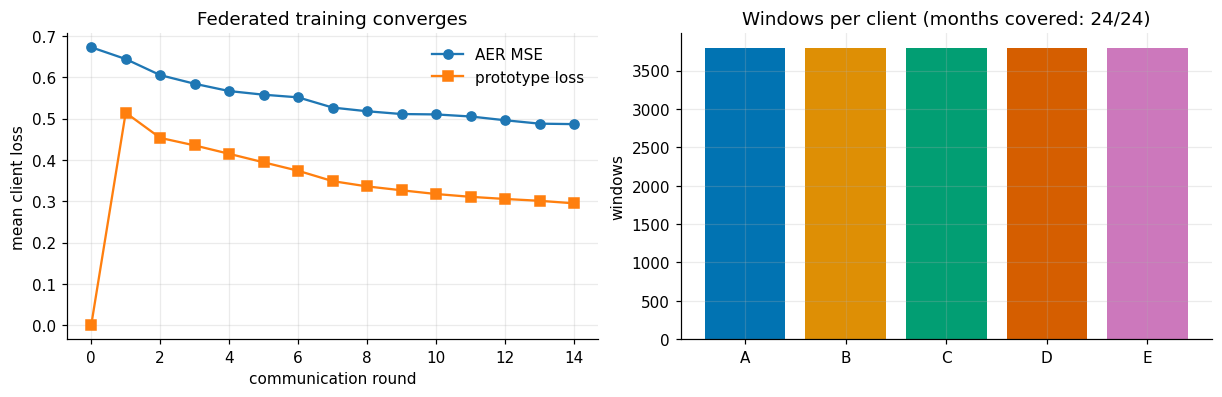

In [2]:
log = art("baseline", "data/08_reporting/fl_training_log.csv")
prep = art("baseline", "data/08_reporting/fl_prep_report.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g = log.groupby("round")[["loss_mse", "loss_proto"]].mean()
axes[0].plot(g.index, g["loss_mse"], "o-", label="AER MSE")
axes[0].plot(g.index, g["loss_proto"], "s-", label="prototype loss")
axes[0].set(xlabel="communication round", ylabel="mean client loss",
            title="Federated training converges"); axes[0].legend(frameon=False)
piv = prep.pivot(index="client", columns="check", values="value")
axes[1].bar(range(5), piv["n_windows"], color=[CLR[c] for c in piv.index])
axes[1].set_xticks(range(5), [c[-1] for c in piv.index])
axes[1].set(ylabel="windows", title="Windows per client (months covered: "
            f"{int(piv['months_covered'].min())}/{24})")
save(fig, "fl01_backbone_sanity")

## Act II — Drift detection: right, and wrong for the right reason

Same detector, two worlds. **Isolated**: District D ranks 1st, zero false
alarms, monotone escape of its prototype trajectory. **Coupled baseline**:
every client's prototypes track the *system* pressure decline that D's
growth imposes through the shared network — client-local drift detection
cannot attribute drift under dependence. This is the dissertation's problem
statement, reproduced end-to-end.

saved fl02_drift_contrast


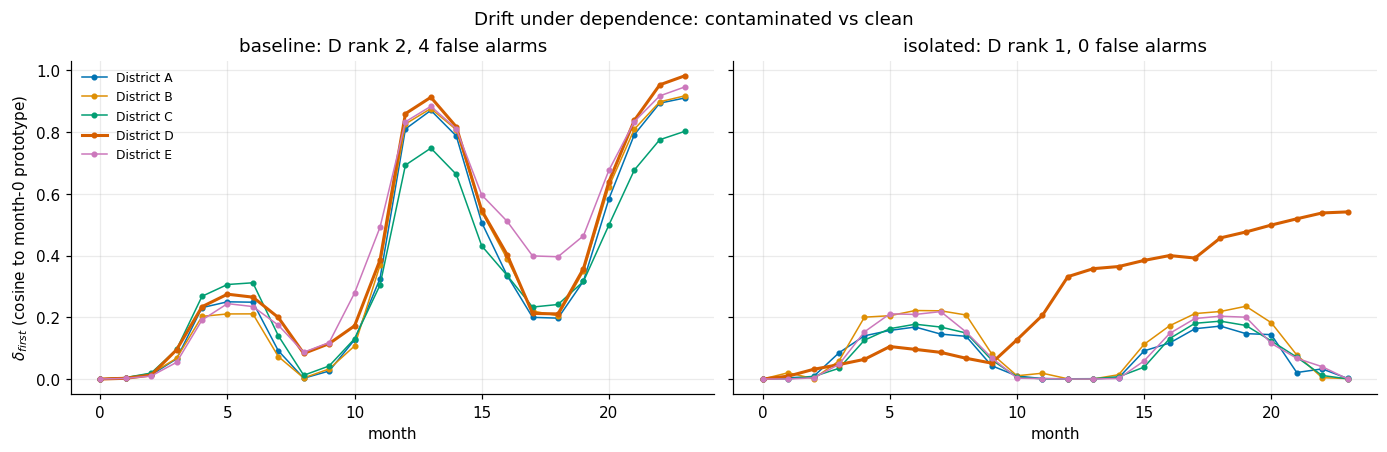

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
for ax, world in zip(axes, ["baseline", "isolated"]):
    sig = art(world, "data/07_model_output/drift_signals.csv")
    for c, g in sig.groupby("client"):
        ax.plot(g["month"], g["delta_first"], "o-", ms=3, color=CLR[c],
                lw=2 if c == "District_D" else 1,
                label=c.replace("_", " ") if world == "baseline" else None)
    rep = art(world, "data/08_reporting/drift_report.csv")
    s = rep[rep.client == "__summary__"].iloc[0]
    ax.set(xlabel="month", title=f"{world}: D rank {int(s['rank'])}, "
           f"{int(s['false_alarms'])} false alarms")
axes[0].set_ylabel(r"$\delta_{first}$ (cosine to month-0 prototype)")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Drift under dependence: contaminated vs clean")
save(fig, "fl02_drift_contrast")

## Act III — Dependence: what and how

Three communication budgets: **P** (prototypes the server already holds),
**T** (per-window latents in the shared FedAvg encoder space), **R** (the
centralized oracle battery = upper bound). Quantity: **RV coefficient** —
bounded [0,1], the share of co-inertia between two clients' latent dynamics;
**partial RV** conditions on all other clients (direct vs mediated).
Sanity first: month+phase+weekday residualization must kill the shared
seasonal confound — checked on the isolated world, where any dependence is
spurious by construction.

saved fl03_residualization_sanity


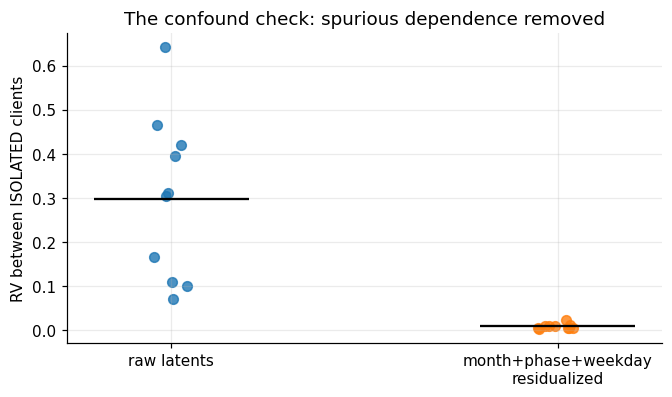

In [4]:
from fedwater.pipelines.dependence_oracle.methods import rv_coefficient
raw = pd.read_parquet(Path(WORLDS["isolated"]) / "data/07_model_output/latent_trajectories.parquet")
res = pd.read_parquet(Path(WORLDS["isolated"]) / "data/07_model_output/latent_trajectories_residualized.parquet")
fcols = [c for c in raw.columns if c.startswith("f")]
def pair_rvs(df):
    mats = {c: g.sort_values("window")[fcols].to_numpy() for c, g in df.groupby("district")}
    ks = sorted(mats)
    return [rv_coefficient(mats[a], mats[b]) for i, a in enumerate(ks) for b in ks[i+1:]]
fig, ax = plt.subplots(figsize=(6, 3.5))
for i, (lab, v) in enumerate([("raw latents", pair_rvs(raw)),
                              ("residualized", pair_rvs(res))]):
    ax.scatter(np.full(10, i) + np.random.uniform(-.05, .05, 10), v, s=40, alpha=.8)
    ax.hlines(np.mean(v), i-.2, i+.2, color="k")
ax.set_xticks([0, 1], ["raw latents", "month+phase+weekday\nresidualized"])
ax.set(ylabel="RV between ISOLATED clients",
       title="The confound check: spurious dependence removed")
save(fig, "fl03_residualization_sanity")

## Act IV — Results on the coupled baseline

Left: the quantified dependence matrix (RV — every pair significant at
q<0.05, as physics demands on a single-source network) and the **partial RV**
matrix, where the global common mode is conditioned away and the direct
boundary structure emerges. Right: structure recovery — the federated
latent-space methods **beat every centralized raw-data method**, with partial
RV at AUROC 1.00.

saved fl04_dependence_results


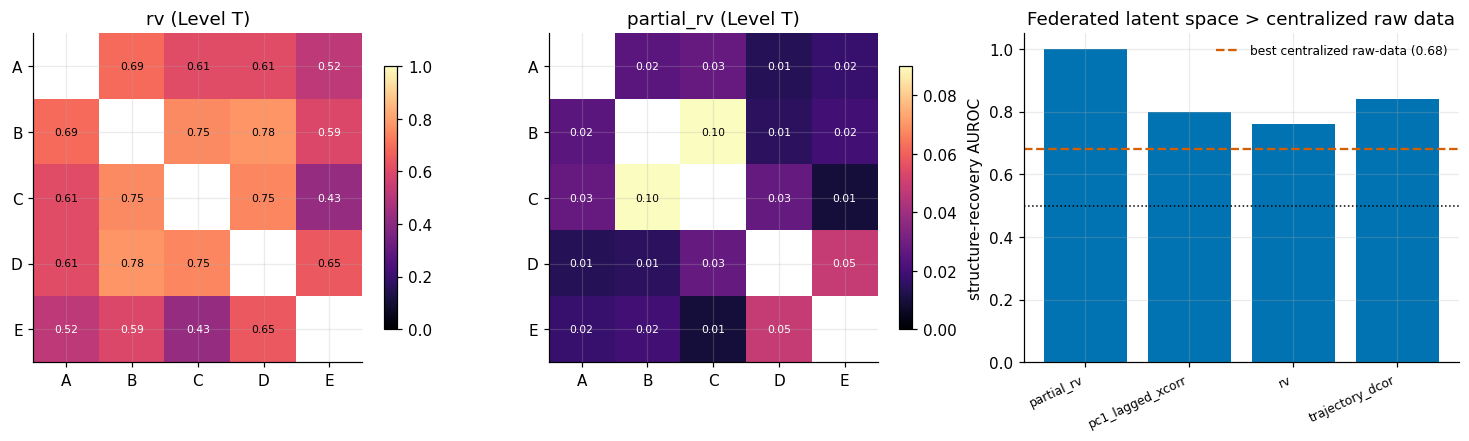

In [5]:
dep = art("baseline", "data/08_reporting/client_dependence.csv")
def mat(df, method):
    ds = [f"District_{x}" for x in "ABCDE"]; M = pd.DataFrame(np.nan, ds, ds)
    for _, r in df[(df.level=="T") & (df.method==method)].iterrows():
        M.loc[r.district_a, r.district_b] = M.loc[r.district_b, r.district_a] = abs(r.statistic)
    return M
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
for ax, m, vmax in [(axes[0], "rv", 1.0), (axes[1], "partial_rv", 0.09)]:
    Mx = mat(dep, m); im = ax.imshow(Mx, cmap="magma", vmin=0, vmax=vmax)
    ax.set_xticks(range(5), list("ABCDE")); ax.set_yticks(range(5), list("ABCDE"))
    ax.set_title(f"{m} (Level T)"); plt.colorbar(im, ax=ax, shrink=.8)
    for (a, b), v in np.ndenumerate(Mx.values):
        if a != b: ax.text(b, a, f"{v:.2f}", ha="center", va="center", fontsize=7,
                           color="white" if v < .6*vmax else "black")
ev = art("baseline", "data/08_reporting/dependence_evaluation.csv")
sr = ev[(ev.evaluation=="structure_recovery") & (ev.kind=="aer_latent")]
cent = art("baseline", "data/08_reporting/gt_structure_recovery.csv")
best_cent = cent["auroc"].max()
axes[2].bar(range(len(sr)), sr["auroc"], color="#0173b2")
axes[2].axhline(best_cent, color="#d55e00", ls="--",
                label=f"best centralized raw-data ({best_cent:.2f})")
axes[2].axhline(.5, color="k", ls=":", lw=1)
axes[2].set_xticks(range(len(sr)), sr["method"], rotation=25, ha="right", fontsize=8)
axes[2].set(ylabel="structure-recovery AUROC",
            title="Federated latent space > centralized raw data")
axes[2].legend(frameon=False, fontsize=8)
save(fig, "fl04_dependence_results")

## Act V — Validation on the dial, and the budget axis

Left: mean federated dependence across the three worlds — monotone, with a
clean null at isolation (0/10 significant pairs). Middle: Level P
(prototypes) saturates near 1 everywhere — the zero-cost budget cannot
separate coupling from the common trajectory, which is exactly why the
budget axis matters. Right: a first **calibration** read: locating the
baseline's RV on the dial expresses coupling in operational units
("equivalent share of open boundaries").

saved fl05_dial_and_budget
           mean_abs          sig      
level             P      T     P     T
world                                 
baseline      0.957  0.637  10.0  10.0
isolated      0.468  0.008   3.0   0.0
partial_50    0.833  0.397  10.0  10.0


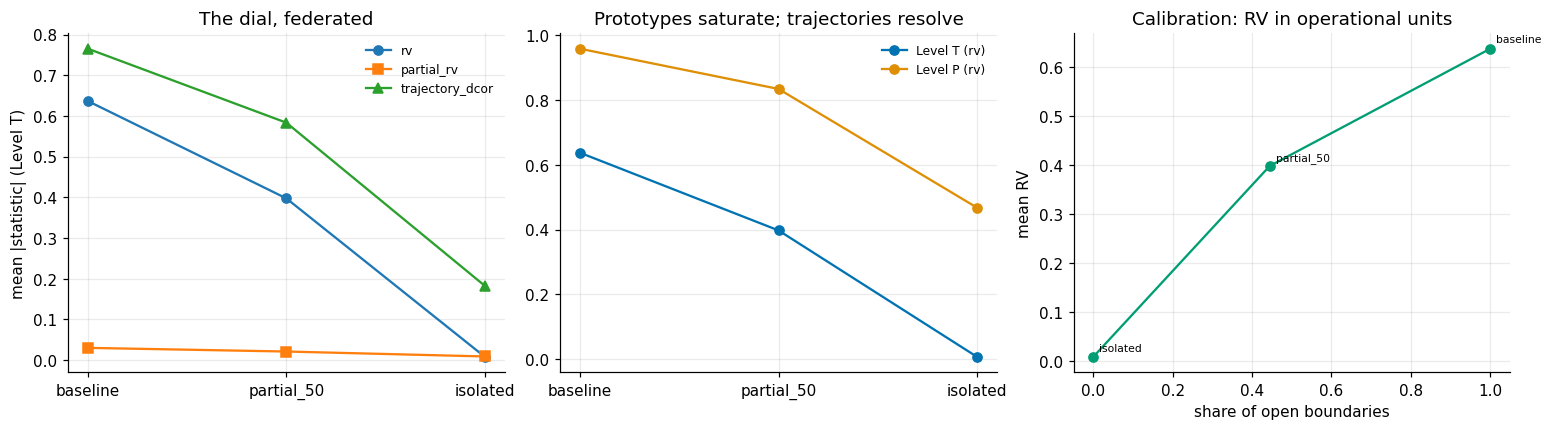

In [6]:
worlds = ["baseline", "partial_50", "isolated"]
rows = []
for w in worlds:
    d = art(w, "data/08_reporting/client_dependence.csv")
    for lv in ["T", "P"]:
        t = d[d.level==lv]
        for m, g in t.groupby("method"):
            rows.append(dict(world=w, level=lv, method=m,
                             mean_abs=g["statistic"].abs().mean(),
                             sig=(g["q_value"]<.05).sum()))
D = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
x = range(3)
for m, mk in [("rv","o"), ("partial_rv","s"), ("trajectory_dcor","^")]:
    y = [D[(D.world==w)&(D.level=="T")&(D.method==m)]["mean_abs"].iloc[0] for w in worlds]
    axes[0].plot(x, y, mk+"-", label=m)
axes[0].set_xticks(x, worlds); axes[0].legend(frameon=False, fontsize=8)
axes[0].set(ylabel="mean |statistic| (Level T)", title="The dial, federated")
for lv, c in [("T","#0173b2"), ("P","#de8f05")]:
    y = [D[(D.world==w)&(D.level==lv)&(D.method=="rv")]["mean_abs"].iloc[0] for w in worlds]
    axes[1].plot(x, y, "o-", color=c, label=f"Level {lv} (rv)")
axes[1].set_xticks(x, worlds); axes[1].legend(frameon=False, fontsize=8)
axes[1].set(title="Prototypes saturate; trajectories resolve")
# calibration: open-boundary share vs rv, linear read-off
open_share = [1.0, 4/9, 0.0]
rv_t = [D[(D.world==w)&(D.level=="T")&(D.method=="rv")]["mean_abs"].iloc[0] for w in worlds]
axes[2].plot(open_share, rv_t, "o-", color="#029e73")
for s_, r_, w in zip(open_share, rv_t, worlds):
    axes[2].annotate(w, (s_, r_), fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[2].set(xlabel="share of open boundaries", ylabel="mean RV",
            title="Calibration: RV in operational units")
save(fig, "fl05_dial_and_budget")
print(D[D.method=="rv"].pivot_table(index="world", columns="level",
      values=["mean_abs","sig"]).round(3).to_string())

## Closing

The backbone stands: drift detection works and fails exactly where physics
says it must; dependence is **detected** (10/10 significant pairs on the
coupled network, 0/10 on isolated) and **quantified** (RV 0.64 -> 0.40 ->
0.01 along the dial); and conditioning inside the shared latent space
(partial RV, AUROC 1.00) recovers the physical boundary structure better
than any centralized raw-data method — at a communication cost of one latent
trajectory per client. Next: the dependence-aware drift detector — use the
estimated dependence structure to correct delta signals on the coupled
network and close the rank-2/4-false-alarms gap against the isolated ideal.